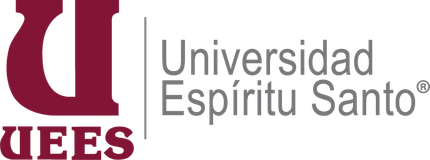

<div style="background:#821436;color:#FFFFFF;padding:14px 18px;border-radius:10px;margin:6px 0 12px 0"><div style="font-size:12px;letter-spacing:.08em;text-transform:uppercase;opacity:.9">Aprendizaje Automático · MIAR0525 · Semana 1 · Versión resuelta · referencia</div><div style="font-size:22px;font-weight:700;margin-top:4px">E1.3 · Fuga de datos y pipelines</div><div style="font-size:12px;opacity:.9;margin-top:4px">Postgrado · Maestría en Inteligencia Artificial · UEES</div></div>

| | |
|---|---|
| **Objetivo** | Prevenir la fuga de datos por construcción y armar el flujo que usarás en todas las tareas. |
| **Resultado de aprendizaje** | RDA1 · competencias CG-G1 y CE-G1 |
| **Duración** | ≈ 5 h · es la **base de la Tarea 1** |
| **Teoría** | Manual M1 §5 (validación) y §7 (fuga de datos) · Animación A1.4 · Video V1.2 · BC3 |
| **Datos** | Ruido sintético · **Titanic** (OpenML 40945; 1309 pasajeros, tipos mixtos y valores faltantes) |

**Niveles:** 1 · la fuga en acción → 2 · `Pipeline` y `ColumnTransformer` → 3 · Titanic de principio a fin → 4 · detecta la fuga.

## 0 · Configuración

In [1]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn
from cycler import cycler

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", message=".*zero_division.*|.*Precision is ill-defined.*")
SEED = 2026
UEES = {"vino": "#821436", "azul": "#1F6F8B", "ocre": "#C28E0E", "verde": "#3A7D44", "gris": "#77787B"}
plt.rcParams.update({
    "axes.prop_cycle": cycler(color=list(UEES.values())), "axes.titlecolor": UEES["vino"],
    "axes.titleweight": "bold", "axes.edgecolor": UEES["gris"], "axes.grid": True, "grid.color": "#EEE8EA",
    "axes.spines.top": False, "axes.spines.right": False, "figure.dpi": 110, "legend.frameon": False,
})
print(f"scikit-learn {sklearn.__version__} · semilla {SEED}")

scikit-learn 1.9.1 · semilla 2026


## Nivel 1 · La fuga en acción

60 filas, **1000 variables de ruido puro** y etiquetas asignadas al azar: ningún modelo honesto puede superar el 50 % de exactitud. Vamos a elegir las 10 variables "más relacionadas" con la etiqueta de dos maneras.

In [2]:
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import make_pipeline

rng = np.random.default_rng(SEED)
X_ruido = rng.normal(size=(60, 1000))
y_ruido = rng.permutation(np.repeat([0, 1], 30))
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

# ✗ CON FUGA: la selección mira las 60 filas (incluidas las que después servirán de validación)
selector = SelectKBest(f_classif, k=10).fit(X_ruido, y_ruido)
acc_fuga = cross_val_score(LogisticRegression(max_iter=1000), selector.transform(X_ruido), y_ruido, cv=cv).mean()

# ✓ SIN FUGA: la selección va dentro del pipeline y se reajusta en cada fold
# TODO: arma un pipeline SelectKBest(f_classif, k=10) + LogisticRegression y evalúalo con cross_val_score.
pipe_ruido = make_pipeline(SelectKBest(f_classif, k=10), LogisticRegression(max_iter=1000))
acc_limpia = cross_val_score(pipe_ruido, X_ruido, y_ruido, cv=cv).mean()
print(f"Exactitud con fuga: {acc_fuga:.2f} · sin fuga: {acc_limpia:.2f} · azar: 0.50")

Exactitud con fuga: 0.77 · sin fuga: 0.48 · azar: 0.50


### 1.2 Qué hace el pipeline por dentro
El pipeline equivale a este bucle: en cada fold, **todo lo que aprende de los datos** (aquí, la selección) se ajusta solo con las filas de entrenamiento de ese fold.

In [3]:
exactitudes = []
for idx_tr, idx_va in cv.split(X_ruido, y_ruido):
    # TODO: ajusta SelectKBest solo con las filas idx_tr, entrena la regresión y mide la exactitud en idx_va.
    sel = SelectKBest(f_classif, k=10).fit(X_ruido[idx_tr], y_ruido[idx_tr])
    clf = LogisticRegression(max_iter=1000).fit(sel.transform(X_ruido[idx_tr]), y_ruido[idx_tr])
    exactitudes.append(clf.score(sel.transform(X_ruido[idx_va]), y_ruido[idx_va]))
acc_manual = float(np.mean(exactitudes))
print(f"Bucle manual: {acc_manual:.2f} · pipeline: {acc_limpia:.2f}")

Bucle manual: 0.48 · pipeline: 0.48


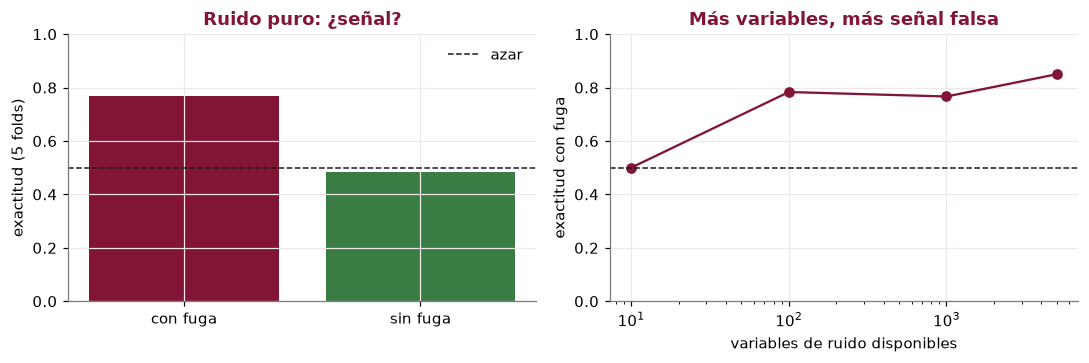

In [4]:
tamanos = [10, 100, 1000, 5000]
curva_fuga = []
for p in tamanos:
    Xp = np.random.default_rng(SEED).normal(size=(60, p))
    sel_p = SelectKBest(f_classif, k=min(10, p)).fit(Xp, y_ruido)
    curva_fuga.append(cross_val_score(LogisticRegression(max_iter=1000), sel_p.transform(Xp), y_ruido, cv=cv).mean())

fig, axes = plt.subplots(1, 2, figsize=(10, 3.4))
axes[0].bar(["con fuga", "sin fuga"], [acc_fuga, acc_limpia], color=[UEES["vino"], UEES["verde"]])
axes[0].axhline(0.5, color="#1C1A1B", ls="--", lw=1, label="azar")
axes[0].set(ylim=(0, 1), ylabel="exactitud (5 folds)", title="Ruido puro: ¿señal?")
axes[0].legend()
axes[1].plot(tamanos, curva_fuga, "o-", color=UEES["vino"])
axes[1].axhline(0.5, color="#1C1A1B", ls="--", lw=1)
axes[1].set(xscale="log", ylim=(0, 1), xlabel="variables de ruido disponibles", ylabel="exactitud con fuga", title="Más variables, más señal falsa")
plt.tight_layout()
plt.show()

**Qué observar.** Con fuga "encontramos" una exactitud muy superior al azar sobre datos que no contienen información. Cuantas más variables hay para elegir, más fácil es encontrar correlaciones casuales con las etiquetas. Es el experimento de la animación A1.4.

## Nivel 2 · `Pipeline` y `ColumnTransformer`
Los datos reales mezclan tipos: números con faltantes y categorías. `ColumnTransformer` aplica a cada grupo de columnas su propio preprocesamiento, y todo queda dentro de un objeto que se ajusta de una sola vez.

In [5]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

clientes = pd.DataFrame({
    "edad": [25, np.nan, 47, 35, 52, 29],
    "ingreso": [1200, 3400, np.nan, 2100, 5000, 1800],
    "plan": ["básico", "premium", "básico", np.nan, "premium", "empresa"],
    "region": ["costa", "sierra", "costa", "oriente", "sierra", "costa"],
})
num_cols, cat_cols = ["edad", "ingreso"], ["plan", "region"]

# TODO: rama numérica (imputar mediana + escalar) y rama categórica (imputar moda + one-hot que ignore categorías nuevas).
preprocesador = ColumnTransformer([
    ("num", Pipeline([("imputar", SimpleImputer(strategy="median")), ("escalar", StandardScaler())]), num_cols),
    ("cat", Pipeline([("imputar", SimpleImputer(strategy="most_frequent")),
                      ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))]), cat_cols),
])
transformado = preprocesador.fit_transform(clientes)
pd.DataFrame(transformado, columns=preprocesador.get_feature_names_out()).round(2)

,num__edad,num__ingreso,cat__plan_básico,cat__plan_empresa,cat__plan_premium,cat__region_costa,cat__region_oriente,cat__region_sierra
0,-1.28,-1.11,1.0,0.0,0.0,1.0,0.0,0.0
1,-0.23,0.64,0.0,0.0,1.0,0.0,0.0,1.0
2,1.04,-0.40,1.0,0.0,0.0,1.0,0.0,0.0
3,-0.23,-0.40,1.0,0.0,0.0,0.0,1.0,0.0
4,1.56,1.91,0.0,0.0,1.0,0.0,0.0,1.0
5,-0.86,-0.64,0.0,1.0,0.0,1.0,0.0,0.0


In [6]:
nuevo = pd.DataFrame({"edad": [40], "ingreso": [np.nan], "plan": ["gobierno"], "region": ["galápagos"]})
print("Cliente con categorías nunca vistas → se transforma sin error:")
print(pd.DataFrame(preprocesador.transform(nuevo), columns=preprocesador.get_feature_names_out()).round(2).to_string())

Cliente con categorías nunca vistas → se transforma sin error:
   num__edad  num__ingreso  cat__plan_básico  cat__plan_empresa  cat__plan_premium  cat__region_costa  cat__region_oriente  cat__region_sierra
0        0.3          -0.4               0.0                0.0                0.0                0.0                  0.0                 0.0


## Nivel 3 · Titanic de principio a fin

Predecimos si un pasajero sobrevivió. Antes de modelar decidimos qué columnas **pueden** usarse: solo las que existían al momento de zarpar.

In [7]:
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split

titanic = fetch_openml(data_id=40945, as_frame=True)
df = titanic.frame
y_t = (df["survived"].astype(str) == "1").astype(int)
print(f"{len(df)} pasajeros · sobrevivió el {y_t.mean():.0%}")
df.isna().mean().sort_values(ascending=False).round(2).rename("proporción de faltantes").to_frame().T

1309 pasajeros · sobrevivió el 38%


,body,cabin,boat,home.dest,age,embarked,fare,sibsp,name,survived,pclass,sex,parch,ticket
proporción de faltantes,0.91,0.77,0.63,0.43,0.2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [8]:
EXCLUIDAS = {
    "name": "identificador en texto libre",
    "ticket": "identificador",
    "cabin": "77 % de faltantes",
    "boat": "FUGA · bote salvavidas asignado durante el hundimiento",
    "body": "FUGA · número de cuerpo recuperado después",
    "home.dest": "texto libre",
}
num_t = ["age", "sibsp", "parch", "fare"]
cat_t = ["pclass", "sex", "embarked"]
X_t = df[num_t + cat_t]
print("Columnas excluidas y por qué:")
for c, motivo in EXCLUIDAS.items():
    print(f"  · {c:<10} {motivo}")

# La prueba se separa ANTES de todo y no se usa hasta el final
Xt_tr, Xt_te, yt_tr, yt_te = train_test_split(X_t, y_t, test_size=0.2, stratify=y_t, random_state=SEED)
print(f"\nentrenamiento: {len(Xt_tr)} · prueba: {len(Xt_te)}")

Columnas excluidas y por qué:
  · name       identificador en texto libre
  · ticket     identificador
  · cabin      77 % de faltantes
  · boat       FUGA · bote salvavidas asignado durante el hundimiento
  · body       FUGA · número de cuerpo recuperado después
  · home.dest  texto libre

entrenamiento: 1047 · prueba: 262


In [9]:
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import cross_validate
from sklearn.tree import DecisionTreeClassifier


def preprocesamiento(num, cat):
    return ColumnTransformer([
        ("num", Pipeline([("imputar", SimpleImputer(strategy="median")), ("escalar", StandardScaler())]), num),
        ("cat", Pipeline([("imputar", SimpleImputer(strategy="most_frequent")),
                          ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))]), cat),
    ])


modelos_t = {
    "baseline (clase mayoritaria)": DummyClassifier(strategy="most_frequent"),
    "regresión logística": Pipeline([("prep", preprocesamiento(num_t, cat_t)), ("clf", LogisticRegression(max_iter=1000))]),
    "árbol (profundidad 4)": Pipeline([("prep", preprocesamiento(num_t, cat_t)),
                                       ("clf", DecisionTreeClassifier(max_depth=4, random_state=SEED))]),
}
metricas_cv = {}
for nombre, modelo in modelos_t.items():
    # TODO: validación cruzada estratificada (cv) con scoring=["accuracy", "f1", "roc_auc"].
    res = cross_validate(modelo, Xt_tr, yt_tr, cv=cv, scoring=["accuracy", "f1", "roc_auc"])
    metricas_cv[nombre] = {m: f"{res['test_' + m].mean():.3f} ± {res['test_' + m].std():.3f}" for m in ("accuracy", "f1", "roc_auc")}
    metricas_cv[nombre]["_acc"] = res["test_accuracy"].mean()
tabla_cv = pd.DataFrame(metricas_cv).T
tabla_cv[["accuracy", "f1", "roc_auc"]]

,accuracy,f1,roc_auc
baseline (clase mayoritaria),0.618 ± 0.001,0.000 ± 0.000,0.500 ± 0.000
regresión logística,0.785 ± 0.013,0.710 ± 0.017,0.843 ± 0.017
árbol (profundidad 4),0.800 ± 0.029,0.711 ± 0.063,0.845 ± 0.023


### Análisis de errores por segmento
Con predicciones **fuera del fold** vemos dónde se equivoca el modelo. Un error promedio bajo puede esconder segmentos donde el modelo falla mucho.

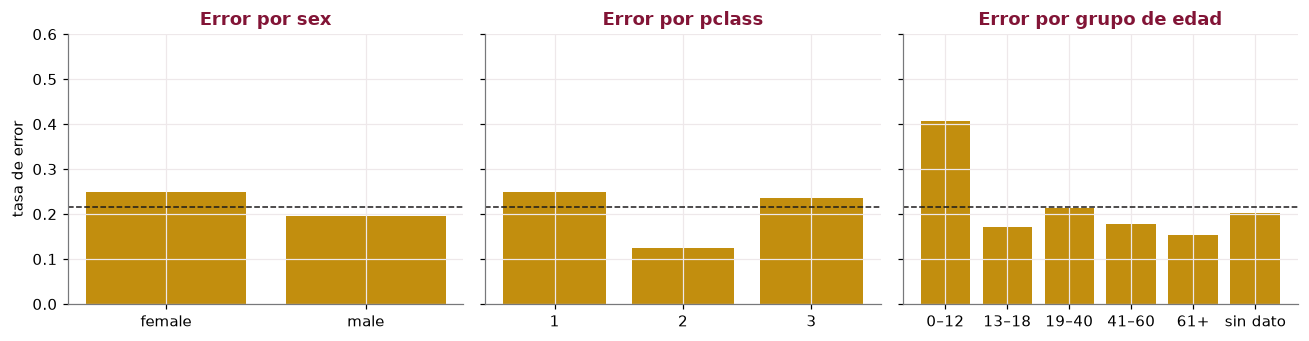

,tasa_error,pasajeros
grupo de edad,,
0–12,0.408,76
13–18,0.171,82
19–40,0.213,494
41–60,0.177,147
61+,0.154,26
sin dato,0.203,222


In [10]:
from sklearn.model_selection import cross_val_predict

pred_oof = cross_val_predict(modelos_t["regresión logística"], Xt_tr, yt_tr, cv=cv)
analisis = Xt_tr.assign(error=(pred_oof != yt_tr.to_numpy()))
grupos = pd.cut(analisis["age"], [0, 12, 18, 40, 60, 100], labels=["0–12", "13–18", "19–40", "41–60", "61+"])
analisis["grupo de edad"] = grupos.cat.add_categories("sin dato").fillna("sin dato")
fig, axes = plt.subplots(1, 3, figsize=(12, 3.2), sharey=True)
for ax, col in zip(axes, ("sex", "pclass", "grupo de edad")):
    tasa = analisis.groupby(col, observed=True)["error"].mean()
    ax.bar(tasa.index.astype(str), tasa.values, color=UEES["ocre"])
    ax.axhline(analisis["error"].mean(), color="#1C1A1B", ls="--", lw=1)
    ax.set(title=f"Error por {col}", ylim=(0, 0.6))
axes[0].set_ylabel("tasa de error")
plt.tight_layout()
plt.show()
analisis.groupby("grupo de edad", observed=True)["error"].agg(tasa_error="mean", pasajeros="size").round(3)

**Qué observar.** El modelo aprende sobre todo la regla "mujeres primero": predice que las mujeres sobreviven y los hombres no. Por eso sus errores se concentran en los **niños de 0 a 12 años** (≈ 40 % de error, el doble del promedio), cuyo destino dependió más de la clase que del sexo, en las mujeres que no sobrevivieron (sobre todo de tercera clase) y en los hombres de primera clase que sí lo hicieron. Un error promedio de ≈ 22 % esconde segmentos donde el modelo falla mucho más: es una **limitación** que debe reportarse, no esconderse (norma g).

### Evaluación final: una sola vez
Elegido el modelo por validación cruzada, lo entrenamos con todo el entrenamiento y lo evaluamos en la prueba.

In [11]:
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

final = modelos_t["regresión logística"].fit(Xt_tr, yt_tr)
p_te = final.predict_proba(Xt_te)[:, 1]
print(f"Prueba · exactitud {accuracy_score(yt_te, p_te >= 0.5):.3f} · F1 {f1_score(yt_te, p_te >= 0.5):.3f} · AUC-ROC {roc_auc_score(yt_te, p_te):.3f}")

Prueba · exactitud 0.794 · F1 0.722 · AUC-ROC 0.821


## Nivel 4 · Detecta la fuga
¿Qué pasa si agregamos `boat` (bote asignado) y `body` (número de cuerpo recuperado)? Mide el efecto con el mismo esquema de validación.

In [12]:
X_fuga = df[num_t + cat_t + ["boat", "body"]]
Xf_tr = X_fuga.loc[Xt_tr.index]
prep_fuga = ColumnTransformer([
    ("num", Pipeline([("imputar", SimpleImputer(strategy="median", add_indicator=True)), ("escalar", StandardScaler())]), num_t + ["body"]),
    ("cat", Pipeline([("imputar", SimpleImputer(strategy="constant", fill_value="ninguno")),
                      ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))]), cat_t + ["boat"]),
])
modelo_fuga = Pipeline([("prep", prep_fuga), ("clf", LogisticRegression(max_iter=2000))])
acc_con_boat = cross_val_score(modelo_fuga, Xf_tr, yt_tr, cv=cv).mean()
acc_sin_boat = tabla_cv.loc["regresión logística", "_acc"]
print(f"Exactitud en validación · sin boat/body: {acc_sin_boat:.3f} · CON boat/body: {acc_con_boat:.3f}")

Exactitud en validación · sin boat/body: 0.785 · CON boat/body: 0.971


**Qué observar.** Con `boat` y `body` la exactitud salta cerca de 1: haber subido a un bote casi equivale a sobrevivir. Pero esa información se registró **durante y después** del hundimiento: al momento de predecir (al zarpar) no existe. Es *target leakage*. La pregunta que debes hacerte por cada variable: **¿tendré este dato cuando haga la predicción?**

## Autoverificación

In [13]:
assert acc_fuga > 0.7, "Con fuga la exactitud sobre ruido debería ser engañosamente alta."
assert acc_limpia < 0.65, "Sin fuga la exactitud sobre ruido debería quedar cerca del azar."
assert np.isclose(acc_manual, acc_limpia), "Tu bucle manual debe dar lo mismo que el pipeline."
assert tabla_cv.loc["regresión logística", "_acc"] > tabla_cv.loc["baseline (clase mayoritaria)", "_acc"] + 0.1
assert acc_con_boat > acc_sin_boat + 0.1, "Las variables con fuga deberían inflar la exactitud."
print("✓ E1.3 completo")

✓ E1.3 completo


## Lista de cotejo (autoevaluación del laboratorio)

- [ ] Reprodujiste la fuga sobre ruido y la corregiste con un pipeline.
- [ ] Todo el preprocesamiento está dentro del pipeline (`ColumnTransformer`).
- [ ] Separaste la prueba al inicio y la usaste una sola vez.
- [ ] Reportaste el baseline y la media ± desviación de cada métrica.
- [ ] Analizaste los errores por segmento y los reportaste como limitación.
- [ ] Explicaste por qué `boat` y `body` son fuga.

**Reflexión:** ¿qué variable de tu trabajo podría ser "del futuro" sin que lo notes?

**Cómo te prepara para la Tarea 1:** la tarea es este mismo flujo aplicado a Telco Customer Churn.

## Desafío opcional con IA agéntica · Caza de fugas

**Objetivo.** Encontrar fugas de datos escondidas por un agente y comparar tu diagnóstico con el suyo.

**Prompt inicial.** Úsalo en la herramienta que prefieras (Claude Code, Codex, Gemini en Colab, ChatGPT…), con este notebook resuelto como contexto. Pide primero un plan y revisa cada paso antes de aprobarlo.

```text
Haz una copia del notebook resuelto E1.3 (fuga de datos y pipelines) e introduce tres fugas de datos sutiles y distintas (por ejemplo: preprocesar antes de partir, seleccionar variables con todos los datos o usar una variable que solo existe después del evento). No me digas cuáles son ni dónde están: dime solo la exactitud que obtiene la copia. Cuando te dé mi diagnóstico, compáralo con lo que hiciste y explica cómo corregir cada fuga con un Pipeline.
```

**Cómo verificar el resultado**

- Buscaste las tres fugas antes de pedir la respuesta.
- Al corregirlas, la exactitud baja a valores realistas.
- Cada corrección usa un Pipeline evaluado con validación cruzada.

**Declara el uso de IA** (norma f del sílabo): herramienta, prompts relevantes, qué verificaste tú y qué corregiste. El desafío es opcional y no se califica; lo que cuenta es que puedas explicar cada decisión.